In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix


# LDA

### Datos sinteticos con misma covarianza

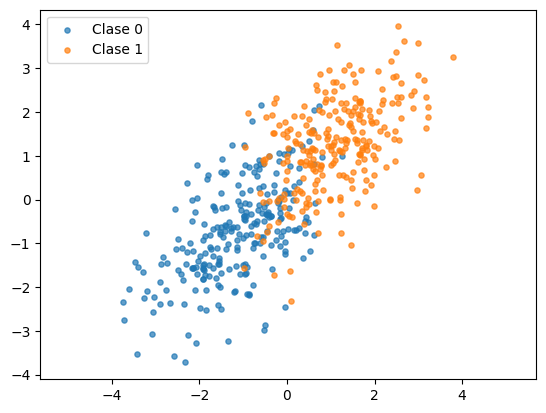

In [2]:
np.random.seed(0)

N0, N1 = 250, 250
mu0 = np.array([-1.2, -0.8])
mu1 = np.array([ 1.0,  1.2])

Sigma = np.array([[1.0, 0.6],
                  [0.6, 1.2]])

X0 = np.random.multivariate_normal(mu0, Sigma, size=N0)
X1 = np.random.multivariate_normal(mu1, Sigma, size=N1)

X = np.vstack([X0, X1])
y = np.hstack([np.zeros(N0, dtype=int), np.ones(N1, dtype=int)])

plt.figure()
plt.scatter(X0[:,0], X0[:,1], s=14, alpha=0.7, label="Clase 0")
plt.scatter(X1[:,0], X1[:,1], s=14, alpha=0.7, label="Clase 1")
plt.legend()
plt.axis("equal")
plt.show()


### LDA from scratch

In [3]:
class LDAFromScratch:
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        N, p = X.shape
        K = len(self.classes_)

        self.pi_ = np.zeros(K)
        self.mu_ = np.zeros((K, p))

        # Estimar priors y medias por clase
        for idx, k in enumerate(self.classes_):
            Xk = X[y == k]
            self.pi_[idx] = Xk.shape[0] / N
            self.mu_[idx] = Xk.mean(axis=0)

        # Estimar matriz de covarianza
        Sigma = np.zeros((p, p))
        for idx, k in enumerate(self.classes_):
            Xk = X[y == k]
            Xc = Xk - self.mu_[idx]
            Sigma += Xc.T @ Xc
        self.Sigma_ = Sigma / N

        self.Sigma_inv_ = np.linalg.inv(self.Sigma_)
        return self

    def decision_function(self, X):
        # δ_k(x) = x^T Σ^{-1} μ_k - 1/2 μ_k^T Σ^{-1} μ_k + log π_k
        scores = []
        for idx in range(len(self.classes_)):
            mu_k = self.mu_[idx]
            term_lin = X @ (self.Sigma_inv_ @ mu_k)
            term_quad = 0.5 * (mu_k.T @ self.Sigma_inv_ @ mu_k)
            term_prior = np.log(self.pi_[idx])
            scores.append(term_lin - term_quad + term_prior)
        return np.vstack(scores).T

    def predict(self, X):
        scores = self.decision_function(X)
        idx = np.argmax(scores, axis=1)
        return self.classes_[idx]


In [4]:
# Entrenar LDA
lda_fs = LDAFromScratch().fit(X, y)
y_pred = lda_fs.predict(X)

acc = (y_pred == y).mean()
print("Train Accuracy LDA:", acc)

print("\nPriors estimados pi_k:", lda_fs.pi_)
print("Medias estimadas mu_k:\n", lda_fs.mu_)
print("Sigma común estimada:\n", lda_fs.Sigma_)


Train Accuracy LDA: 0.896

Priors estimados pi_k: [0.5 0.5]
Medias estimadas mu_k:
 [[-1.15631535 -0.74547317]
 [ 1.09367037  1.25305152]]
Sigma común estimada:
 [[0.95284517 0.55452599]
 [0.55452599 1.15727928]]


### Frontera de decisión

$$ δ_1(x)=δ_0(x) $$

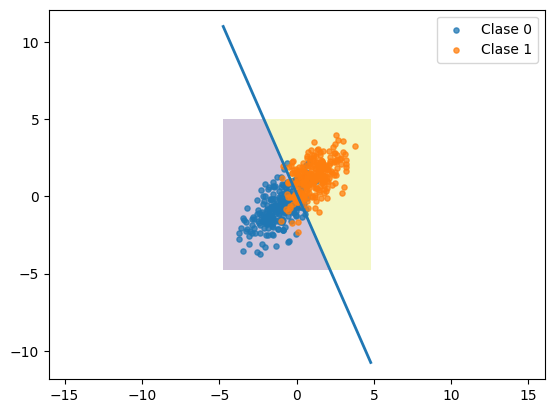

w = [1.88079884 0.82570635]
b = -0.15064403968460327


In [5]:
x_min, x_max = X[:,0].min() - 1.0, X[:,0].max() + 1.0
y_min, y_max = X[:,1].min() - 1.0, X[:,1].max() + 1.0

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))
grid = np.c_[xx.ravel(), yy.ravel()]

scores = lda_fs.decision_function(grid)
Z = np.argmax(scores, axis=1).reshape(xx.shape)

plt.figure()
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(X0[:,0], X0[:,1], s=14, alpha=0.75, label="Clase 0")
plt.scatter(X1[:,0], X1[:,1], s=14, alpha=0.75, label="Clase 1")

# Frontera: δ1(x)-δ0(x)=0
#           δ1-δ0 = w^T x + b
mu0_hat = lda_fs.mu_[0]
mu1_hat = lda_fs.mu_[1]
Sinv = lda_fs.Sigma_inv_

w = Sinv @ (mu1_hat - mu0_hat)
b = -0.5 * (mu1_hat.T @ Sinv @ mu1_hat - mu0_hat.T @ Sinv @ mu0_hat) + np.log(lda_fs.pi_[1]/lda_fs.pi_[0])

# w1*x + w2*y + b = 0 => y = -(w1*x + b)/w2
xs = np.linspace(x_min, x_max, 200)
ys = -(w[0]*xs + b) / w[1]
plt.plot(xs, ys, linewidth=2)

plt.legend()
plt.axis("equal")
plt.show()

print("w =", w)
print("b =", b)


### Scikit-learn

In [6]:
lda_sk = LinearDiscriminantAnalysis(solver="svd")
lda_sk.fit(X, y)
y_pred_sk = lda_sk.predict(X)

print("Train Accuracy LDA:", accuracy_score(y, y_pred_sk))

# Modelo
print("coef_ sklearn:", lda_sk.coef_)
print("intercept_ sklearn:", lda_sk.intercept_)


Train Accuracy LDA: 0.896
coef_ sklearn: [[1.87327564 0.82240353]]
intercept_ sklearn: [-0.15004146]


# Logist Regression

In [7]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix


In [8]:
# Split train/test
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

print("Shapes:", Xtr.shape, Xte.shape)


Shapes: (375, 2) (125, 2)


In [9]:
def add_intercept(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

def sigmoid(t):
    return np.where(t >= 0, 1.0/(1.0 + np.exp(-t)), np.exp(t)/(1.0 + np.exp(t)))

def nll_logistic(beta, Xb, y, reg=0.0):
    # Negative log-likelihood promedio + L2 (sin penalizar intercept)
    eta = Xb @ beta
    p = sigmoid(eta)
    eps = 1e-12
    loss = -(y*np.log(p + eps) + (1-y)*np.log(1-p + eps)).mean()
    if reg > 0:
        loss += 0.5*reg*np.sum(beta[1:]**2)
    return loss

def predict_proba(beta, Xb):
    return sigmoid(Xb @ beta)

def predict_label(beta, Xb, thr=0.5):
    return (predict_proba(beta, Xb) >= thr).astype(int)


### Logistic Regression por Newton–Raphson (IRLS)

In [10]:
class LogisticNewtonIRLS:
    def __init__(self, reg=1e-4, max_iter=30, tol=1e-8):
        self.reg = reg
        self.max_iter = max_iter
        self.tol = tol

    def fit(self, X, y):
        Xb = add_intercept(X)
        N, d = Xb.shape
        beta = np.zeros(d)

        losses = []
        for it in range(self.max_iter):
            eta = Xb @ beta
            p = sigmoid(eta)
            w = p * (1 - p)  # diagonal de W

            # z = eta + (y - p) / (p(1-p))
            z = eta + (y - p) / (w + 1e-12)

            # Resolver (X^T W X + reg*I') beta_new = X^T W z
            # donde I' no penaliza intercept
            Xw = Xb * w[:, None]                 # Nxd
            A = Xb.T @ Xw                        # dxd = X^T W X
            b = Xb.T @ (w * z)                   # dx1 = X^T W z

            if self.reg > 0:
                R = np.eye(d)
                R[0, 0] = 0.0
                A = A + self.reg * R

            beta_new = np.linalg.solve(A, b)

            loss = nll_logistic(beta_new, Xb, y, reg=self.reg)
            losses.append(loss)

            if np.linalg.norm(beta_new - beta) < self.tol:
                beta = beta_new
                break
            beta = beta_new

        self.beta_ = beta
        self.losses_ = np.array(losses)
        return self

    def predict_proba(self, X):
        return predict_proba(self.beta_, add_intercept(X))

    def predict(self, X, thr=0.5):
        return (self.predict_proba(X) >= thr).astype(int)


### Logistic Regression por SGD

In [11]:
class LogisticSGD:
    def __init__(self, reg=1e-4, lr=0.2, epochs=200, batch_size=64, seed=0):
        self.reg = reg
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.seed = seed

    def fit(self, X, y):
        rng = np.random.default_rng(self.seed)
        Xb = add_intercept(X)
        N, d = Xb.shape

        beta = np.zeros(d)
        losses = []

        for ep in range(self.epochs):
            perm = rng.permutation(N)
            Xb_sh = Xb[perm]
            y_sh = y[perm]

            # schedule simple
            lr_ep = self.lr / (1.0 + 0.01*ep)

            for i in range(0, N, self.batch_size):
                Xbatch = Xb_sh[i:i+self.batch_size]
                ybatch = y_sh[i:i+self.batch_size]

                eta = Xbatch @ beta
                p = sigmoid(eta)

                # grad NLL promedio: X^T (p - y) / m
                g = (Xbatch.T @ (p - ybatch)) / Xbatch.shape[0]

                # L2 (sin intercept)
                if self.reg > 0:
                    g[1:] += self.reg * beta[1:]

                beta = beta - lr_ep * g

            losses.append(nll_logistic(beta, Xb, y, reg=self.reg))

        self.beta_ = beta
        self.losses_ = np.array(losses)
        return self

    def predict_proba(self, X):
        return predict_proba(self.beta_, add_intercept(X))

    def predict(self, X, thr=0.5):
        return (self.predict_proba(X) >= thr).astype(int)


### Newton vs SGD

In [12]:
def eval_model(name, y_true, p_hat, y_hat):
    print(f"\n{name} ------ ")
    print("Accuracy:", accuracy_score(y_true, y_hat))
    print("LogLoss :", log_loss(y_true, p_hat))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_hat))

# Newton
t0 = time.perf_counter()
lr_newton = LogisticNewtonIRLS(reg=1e-4, max_iter=30, tol=1e-9).fit(Xtr, ytr)
t1 = time.perf_counter()

# SGD
t2 = time.perf_counter()
lr_sgd = LogisticSGD(reg=1e-4, lr=0.3, epochs=200, batch_size=64, seed=0).fit(Xtr, ytr)
t3 = time.perf_counter()

print("Tiempo Newton (s):", t1 - t0, "| Iteraciones:", len(lr_newton.losses_))
print("Tiempo SGD    (s):", t3 - t2, "| Epochs:", len(lr_sgd.losses_))

# Evaluación en test
p_newton = lr_newton.predict_proba(Xte)
yhat_newton = lr_newton.predict(Xte)

p_sgd = lr_sgd.predict_proba(Xte)
yhat_sgd = lr_sgd.predict(Xte)

eval_model("LogReg Newton/IRLS (test)", yte, p_newton, yhat_newton)
eval_model("LogReg SGD (test)", yte, p_sgd, yhat_sgd)


Tiempo Newton (s): 0.0053296079999967105 | Iteraciones: 8
Tiempo SGD    (s): 0.18361627899999178 | Epochs: 200

LogReg Newton/IRLS (test) ------ 
Accuracy: 0.896
LogLoss : 0.2885181044941047
Confusion matrix:
 [[58  5]
 [ 8 54]]

LogReg SGD (test) ------ 
Accuracy: 0.896
LogLoss : 0.2883008354725768
Confusion matrix:
 [[58  5]
 [ 8 54]]


#### Comparación con LDA

In [13]:
lda_fs_tr = LDAFromScratch().fit(Xtr, ytr)
yhat_lda = lda_fs_tr.predict(Xte)

# Para log-loss LDA necesitaríamos probabilidades; LDA_fs que escribimos retorna scores.
# Aquí comparamos Accuracy y matriz de confusión.
print("\n--- LDA desde cero (test) ---")
print("Accuracy:", accuracy_score(yte, yhat_lda))
print("Confusion matrix:\n", confusion_matrix(yte, yhat_lda))



--- LDA desde cero (test) ---
Accuracy: 0.88
Confusion matrix:
 [[56  7]
 [ 8 54]]


#### Curvas de pérdida (NLL) Newton vs SGD

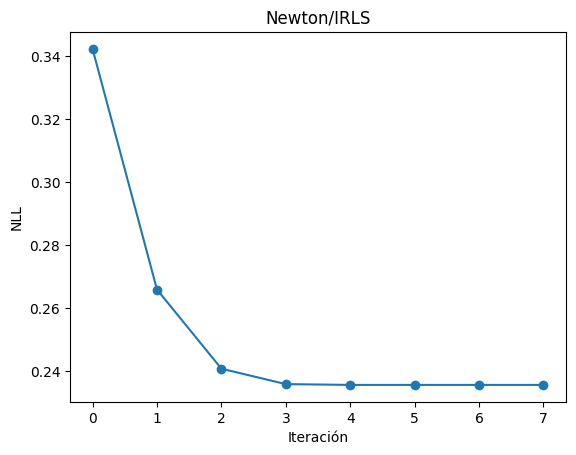

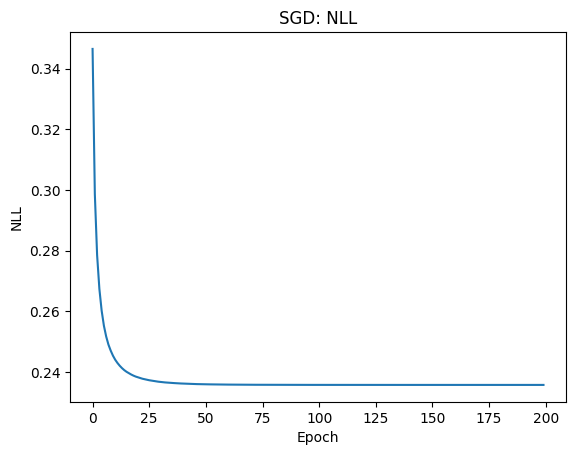

In [14]:
plt.figure()
plt.plot(lr_newton.losses_, marker="o")
plt.title("Newton/IRLS")
plt.xlabel("Iteración")
plt.ylabel("NLL")
plt.show()

plt.figure()
plt.plot(lr_sgd.losses_)
plt.title("SGD: NLL")
plt.xlabel("Epoch")
plt.ylabel("NLL")
plt.show()


### Fronteras de decisión

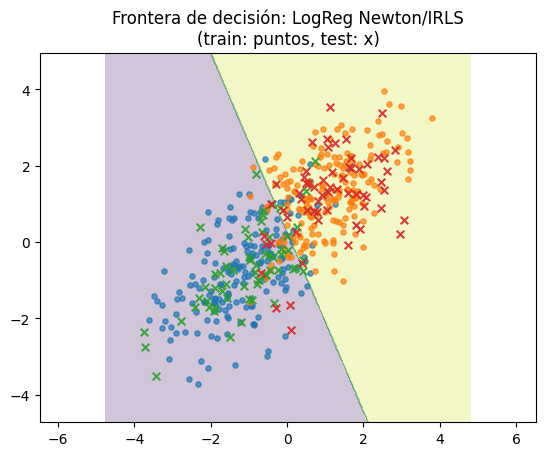

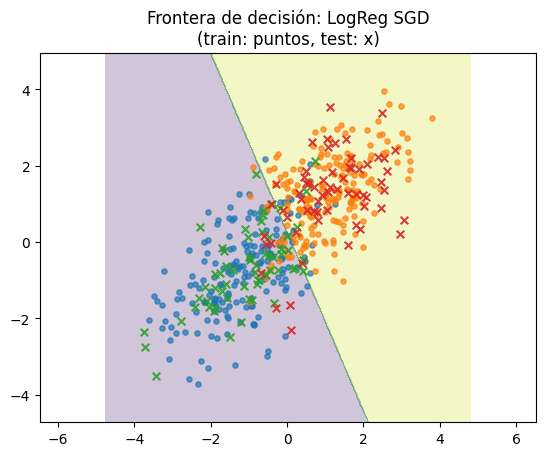

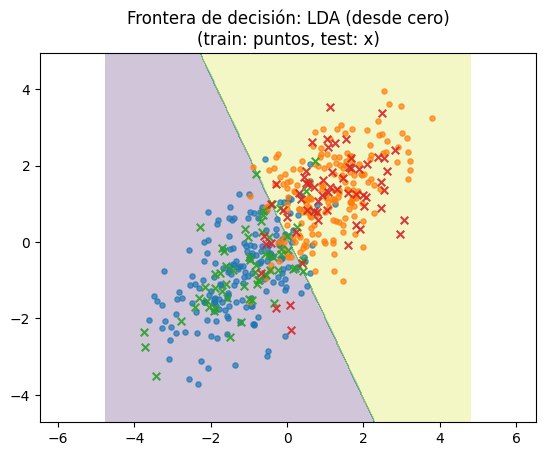

In [15]:
def plot_boundary(models, Xtr, ytr, Xte, yte, grid_n=350):
    x_min, x_max = X[:,0].min() - 1.0, X[:,0].max() + 1.0
    y_min, y_max = X[:,1].min() - 1.0, X[:,1].max() + 1.0

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, grid_n),
                         np.linspace(y_min, y_max, grid_n))
    grid = np.c_[xx.ravel(), yy.ravel()]

    for name, pred_fn in models:
        Z = pred_fn(grid).reshape(xx.shape)

        plt.figure()
        plt.contourf(xx, yy, Z, alpha=0.25)
        plt.scatter(Xtr[ytr==0,0], Xtr[ytr==0,1], s=14, alpha=0.7)
        plt.scatter(Xtr[ytr==1,0], Xtr[ytr==1,1], s=14, alpha=0.7)
        plt.scatter(Xte[yte==0,0], Xte[yte==0,1], s=30, marker="x", alpha=0.9)
        plt.scatter(Xte[yte==1,0], Xte[yte==1,1], s=30, marker="x", alpha=0.9)
        plt.title(f"Frontera de decisión: {name}\n(train: puntos, test: x)")
        plt.axis("equal")
        plt.show()

models = [
    ("LogReg Newton/IRLS", lambda G: lr_newton.predict(G)),
    ("LogReg SGD",         lambda G: lr_sgd.predict(G)),
    ("LDA (desde cero)",   lambda G: lda_fs_tr.predict(G))
]

plot_boundary(models, Xtr, ytr, Xte, yte)


In [16]:
# Resumen
results = []
results.append(("LogReg Newton/IRLS", accuracy_score(yte, yhat_newton), log_loss(yte, p_newton)))
results.append(("LogReg SGD",         accuracy_score(yte, yhat_sgd),    log_loss(yte, p_sgd)))
results.append(("LDA (acc only)",     accuracy_score(yte, yhat_lda),    np.nan))

for name, acc, ll in results:
    print(name.ljust(18), " | acc:", round(acc, 4), " | logloss:", ll if np.isnan(ll) else round(ll, 4))


LogReg Newton/IRLS  | acc: 0.896  | logloss: 0.2885
LogReg SGD          | acc: 0.896  | logloss: 0.2883
LDA (acc only)      | acc: 0.88  | logloss: nan
